# 聚类算法

## K-MEANS
k：将事先输入的n个数据对象划分为k个聚类，以便使得所获得的聚类满足：同一聚类中的对象相似度较高；而不同聚类中的对象相似度较小

算法思想：以空间中k个点为中心进行聚类，对最靠近他们的对象归类，通过迭代的方法，逐次更新各聚类中心的值，直到得到最好的聚类结果

## k值选择
肘部法则

In [78]:
import numpy as np
import matplotlib.pyplot as plt

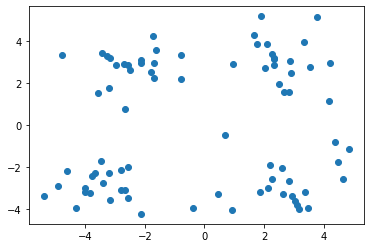

(80, 2)

In [150]:
data = np.genfromtxt('kmeans.txt', delimiter=' ')
plt.scatter(data[:,0],data[:,1])
plt.show()
data.shape

In [151]:
# 计算距离
def euclDistance(vector1, vector2):
  return np.sqrt(sum(vector2 - vector1) ** 2)

# 初始化质心
def initCentroids(data, k):
  numSamples, dim = data.shape
  # k个质心，列数和样本列数一样
  centroids = np.zeros((k,dim))
  # 随机选出k个质心
  for i in range(k):
    # 随机选取一个样本的索引 
    index = int(np.random.uniform(0, numSamples))
    # 作为初始化的质心
    centroids[i, :] = data[index, :]
  return centroids

# 传入数据集和k的值
def kmeans(data, k):
  # 计算样本个数 
  numSamples = data.shape[0]
  # 样本属性，第一列保存该样本属于哪个簇，第二列保存该样本和它所属簇的误判
  clusterData = np.array(np.zeros((numSamples, 2)))
  # 决定质心是否要改变的变量
  clusterChanged = True
  # 初始化质心
  centroids = initCentroids(data, k)
  while clusterChanged:
    clusterChanged = False
    # 循环每个样本
    for i in range(numSamples):
      # 最小距离
      minDist = 100000.0
      # 定义样本所属簇
      minIndex = 0
      # 循环计算每个质心与该样本的距离
      for j in range(k):
        # 循环每个质心和样本，计算距离
        distance = euclDistance(centroids[j, :], data[i, :])
        # 如果计算的距离小于最小距离，则更新最小距离
        if distance < minDist:
          minDist = distance
          # 更新样本所属簇
          minIndex = j
          # 更新最小距离
          clusterData[i, 1] = distance

      # 如果样本所属的簇发生变化
      if clusterData[i,0] != minIndex:
        # 质心重新计算
        clusterChanged = True
        # 更新样本的簇
        clusterData[i, 0] = minIndex

    # 更新质心
    for j in range(k):
      # 获取第j个簇所有的样本所在的索引
      cluster_index = np.nonzero(clusterData[:,0] == j)
      # 第j个簇所有的样本点
      pointsInCluster = data[cluster_index]
      # 计算质心
      centroids[j, :] = np.mean(pointsInCluster, axis = 0)

    return centroids, clusterData

def showCluster(data, k, centroids, clusterData):
  numSamples, dim = data.shape
  if dim != 2:
    return 1
  # 用不同颜色形状表示各个类别
  mark = ['or', 'ob', 'og', 'ok', '^r', '+r', 'sr', 'dr', '<r', 'pr']
  if k > len(mark):
    return 1
  for i in range(numSamples):
    markIndex = int(clusterData[i, 0])
    plt.plot(data[i, 0], data[i, 1], mark[markIndex])

  mark = ['*r', '*b', '*g', '*k', '^b', '+b', 'sb', 'db', '<b', 'pb']
  for i in range(k):
    plt.plot(centroids[i, 0], centroids[i, 1], mark[i], markersize = 20)
  plt.show()

## 存在问题
与初始质心位置关系较大

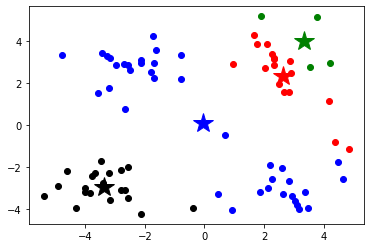

In [160]:
# 设置k值
k = 4
centroids, clusterData = kmeans(data, k)
if np.isnan(centroids).any():
  print("error")
showCluster(data, k, centroids, clusterData)

解决：使用多次随机初始化，计算每次建模得到的代价函数的值，选取代价函数最小结果作为聚类结果

$$
J(c^{(1)},..,c^{(m)},\mu_1,... ,\mu_K) = \frac{1}{m} \sum_{i=1}^m ||x^{(i)} - \mu_c^{(i)}||^2
$$

/usr/local/lib/python3.6/dist-packages/numpy/core/fromnumeric.py:3335: RuntimeWarning: Mean of empty slice.
  out=out, **kwargs)
/usr/local/lib/python3.6/dist-packages/numpy/core/_methods.py:154: RuntimeWarning: invalid value encountered in true_divide
  ret, rcount, out=ret, casting='unsafe', subok=False)


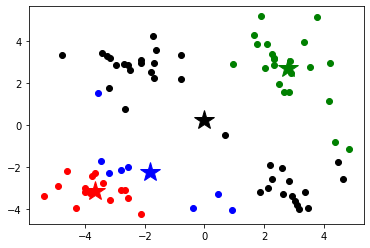

In [168]:
# 设置k值
k = 4
min_loss = 10000
min_loss_centroids = np.array([])
min_loss_clusterData = np.array([])
for i in range(50):
  centroids, clusterData = kmeans(data, k)
  loss = sum(clusterData[:, 1]) / data.shape[0]
  if loss < min_loss:
    min_loss = loss
    min_loss_centroids = centroids
    min_loss_clusterData = clusterData

centroids = min_loss_centroids
clusterData = min_loss_clusterData
showCluster(data, k, centroids, clusterData)

In [69]:
# 预测
x_test = [0,1]
np.tile(x_test, (k,1))
# 误差平方和
sqrs = ((np.tile(x_test, (k,1)) - centroids) ** 2).sum(axis=1)
# 最小值所在索引号
np.argmin(sqrs)
def predict(datas):
  return np.array([np.argmin(((np.tile(data, (k,1)) - centroids) ** 2).sum(axis=1))for data in datas])

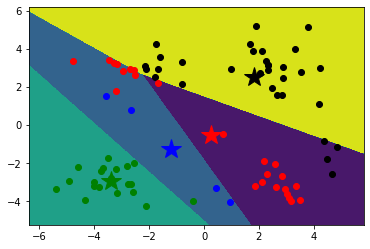

In [73]:
x_min, x_max = data[:, 0].min() - 1, data[:, 0].max() + 1
y_min, y_max = data[:, 1].min() - 1, data[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))
z = predict(np.c_[xx.ravel(), yy.ravel()])
z = z.reshape(xx.shape)
cs = plt.contourf(xx, yy, z)
showCluster(data, k, centroids, clusterData)

## sklearn-k-means

In [82]:
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt

In [88]:
data = np.genfromtxt('kmeans.txt', delimiter=' ')
k = 4
model = KMeans(n_clusters=k)
model.fit(data)

KMeans(algorithm='auto', copy_x=True, init='k-means++', max_iter=300,
       n_clusters=4, n_init=10, n_jobs=None, precompute_distances='auto',
       random_state=None, tol=0.0001, verbose=0)

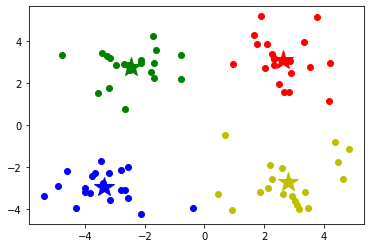

In [99]:
centers = model.cluster_centers_
result = model.predict(data)
mark = ['or', 'ob', 'og', 'oy']
for i,d in enumerate(data):
  plt.plot(d[0], d[1], mark[result[i]])

mark = ['*r', '*b', '*g', '*y']
for i,center in enumerate(centers):
  plt.plot(center[0], center[1], mark[i], markersize = 20)
plt.show()

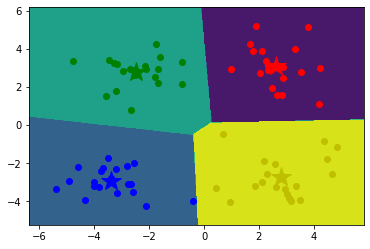

In [101]:
x_min, x_max = data[:, 0].min() - 1, data[:, 0].max() + 1
y_min, y_max = data[:, 1].min() - 1, data[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))
z = model.predict(np.c_[xx.ravel(), yy.ravel()])
z = z.reshape(xx.shape)
cs = plt.contourf(xx, yy, z)

mark = ['or', 'ob', 'og', 'oy']
for i,d in enumerate(data):
  plt.plot(d[0], d[1], mark[result[i]])

mark = ['*r', '*b', '*g', '*y']
for i,center in enumerate(centers):
  plt.plot(center[0], center[1], mark[i], markersize = 20)
plt.show()

## Mini Batch K-Means
Mini Batch K-Means算法是K-Means算法的变种，采用小批量的数据子集减小计算时间。所谓的小批量是指每次训练算法时所随机抽取的数据子集，采用这些随机产生的子集进行训练算法，大大减小了计算时间，结果一般只略差于标准算法



In [ ]:
from sklearn.cluster import MiniBatchKMeans
# 其它同KMeans一样
model = MiniBatchKMeans(n_clusters=k)

## DBSCAN
DBSCAN(Density-Based Saptial Clustering of Applications with Noise:基于密度的聚类方法)，可以将具有足够高密度的区域划分为簇，并可以发现任何形状的聚类

In [1]:
from sklearn.cluster import DBSCAN
import numpy as np
import matplotlib.pyplot as plt

In [3]:
data = np.genfromtxt('kmeans.txt', delimiter=' ')

In [4]:
# eps：距离阈值
# min_samples:核心对象在eps邻域的样本数阈值
model = DBSCAN(eps = 1,min_samples=4)
model.fit(data)

DBSCAN(algorithm='auto', eps=1, leaf_size=30, metric='euclidean',
       metric_params=None, min_samples=4, n_jobs=None, p=None)

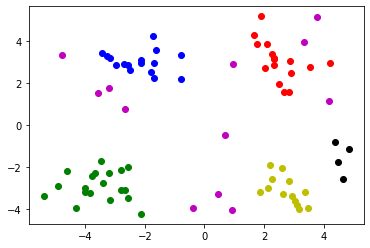

In [7]:
result = model.fit_predict(data)
mark = ['or', 'ob', 'og', 'oy', 'ok', 'om']
for i,d in enumerate(data):
  plt.plot(d[0], d[1], mark[result[i]])

plt.show()

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets

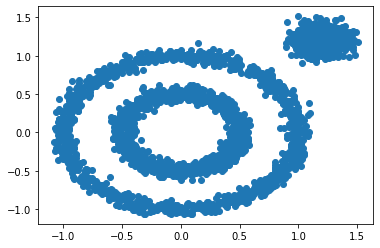

In [9]:
x1, y1 = datasets.make_circles(n_samples=2000, factor=0.5, noise=0.05)
x2, y2 = datasets.make_blobs(n_samples=1000, centers=[[1.2,1.2]], cluster_std=[[.1]])

x = np.concatenate((x1,x2))
plt.scatter(x[:, 0], x[:, 1], marker='o')
plt.show()

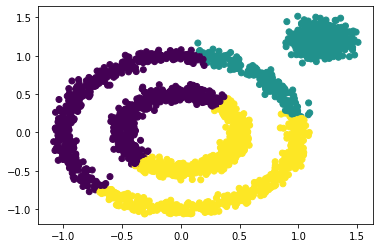

In [10]:
from sklearn.cluster import KMeans
y_pred = KMeans(n_clusters=3).fit_predict(x)
plt.scatter(x[:,0], x[:,1], c=y_pred)
plt.show()

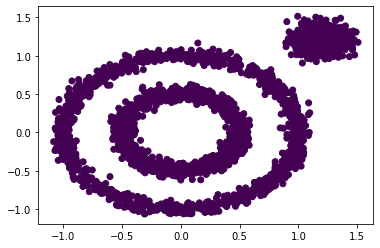

In [11]:
from sklearn.cluster import DBSCAN
y_pred = DBSCAN().fit_predict(x)
plt.scatter(x[:,0], x[:,1],c=y_pred)
plt.show()

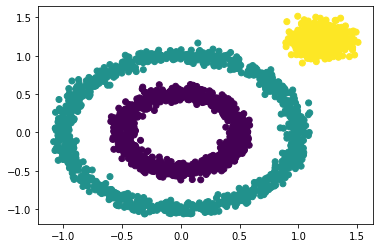

In [13]:
y_pred = DBSCAN(eps=0.2, min_samples=50).fit_predict(x)
plt.scatter(x[:,0], x[:,1],c=y_pred)
plt.show()